# 5주차 과제 - XAI

안녕하세요! 모두들 5주차 세션까지 오시느라 수고 많으셨습니다 😊  
이번 과제에서는 세션에서 소개한 대표적인 XAI 기법 중 **SHAP, Grad-CAM**을 간단히 구현해 보면서 각각의 특징과 활용 방법을 직접 살펴보겠습니다.




## 1번
먼저, 의료 데이터(Stroke Prediction Data)를 활용해 간단한 예측 모델을 만들고,  
**SHAP**을 이용해 **모델이 어떤 근거로 판단했는지** 직접 확인해보겠습니다.  

특히 SHAP은 의료 데이터 분석에서 **특정 환자의 예측 근거를 설명**할 때 자주 사용되는 기법입니다.  
먼저 뇌졸중 예측 데이터셋을 이용하여 모델을 만들고, global/local 설명을 출력해보도록 하겠습니다.

### 1) Import Library


In [1]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import shap
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED); random.seed(SEED)


### 2) Data Load
KaggleHub을 이용해 Stroke Prediction Dataset을 불러옵니다.  


In [2]:
USE_KAGGLEHUB = True # KaggleHub를 사용해서 데이터 로드하겠다.
df = None
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "healthcare-dataset-stroke-data.csv"
df = kagglehub.load_dataset( # 지정된 Kaggle 데이터셋을 로드하여 df 변수에 할당
      KaggleDatasetAdapter.PANDAS,
      "fedesoriano/stroke-prediction-dataset",
      file_path,
      )

print("데이터 크기:", df.shape)
df.head()


Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
데이터 크기: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['hypertension'].plot(kind='hist', bins=20, title='hypertension')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_5.groupby('work_type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('Residence_type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_7.groupby('smoking_status').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8.plot(kind='scatter', x='index', y='id', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_9.plot(kind='scatter', x='id', y='age', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_10.plot(kind='scatter', x='age', y='hypertension', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_11.plot(kind='scatter', x='hypertension', y='heart_disease', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_12.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('gender')):
  _plot_series(series, series_name, i)
  fig.legend(title='gender', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('id')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_13.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('work_type')):
  _plot_series(series, series_name, i)
  fig.legend(title='work_type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('id')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_14.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Residence_type')):
  _plot_series(series, series_name, i)
  fig.legend(title='Residence_type', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('id')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['id']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_15.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('smoking_status')):
  _plot_series(series, series_name, i)
  fig.legend(title='smoking_status', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('id')

from matplotlib import pyplot as plt
_df_16['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_17['id'].plot(kind='line', figsize=(8, 4), title='id')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_18['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_19['hypertension'].plot(kind='line', figsize=(8, 4), title='hypertension')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['work_type'].value_counts()
    for x_label, grp in _df_20.groupby('gender')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('gender')
_ = plt.ylabel('work_type')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Residence_type'].value_counts()
    for x_label, grp in _df_21.groupby('work_type')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('work_type')
_ = plt.ylabel('Residence_type')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['smoking_status'].value_counts()
    for x_label, grp in _df_22.groupby('Residence_type')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Residence_type')
_ = plt.ylabel('smoking_status')

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_23['gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_23, x='index', y='gender', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_24['work_type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_24, x='index', y='work_type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_25['Residence_type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_25, x='index', y='Residence_type', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_26['smoking_status'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_26, x='index', y='smoking_status', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

### 3) Data Preprocessing
- 불필요 컬럼(id) 제거  
- `gender`의 희귀값(Other)을 최빈값으로 대체  
- 수치형: 평균 대치 + 표준화  
- 범주형: 최빈 대치 + 원-핫 인코딩

가장 기본적이고 표준적인 전처리 방법을 적용했습니다. 더 정교한 처리가 필요하다고 생각되면 자유롭게 전처리를 추가해 보셔도 좋습니다 :)

In [3]:
target_col = "stroke" # stroke 열을 target 변수로 지정한다.
df = df.drop(columns=["id"], errors="ignore") # id 열을 데이터에서 제거한다.
# errors="ignore"는 만약 id 열이 존재하지 않더라도 에러를 발생시키지 않도록 한다.

X = df.drop(columns=[target_col]) # 뇌졸중 여부를 제외한 나머지 데이터를 X에 할당한다.
y = df[target_col].astype(int)

num_cols = X.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# 수치형 데이터 처리 위한 파이프라인 정의
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")), # 결측값을 평균으로 대체
    ("scaler", StandardScaler()) # 수치형 데이터의 표준화를 수행
])

# 범주형 데이터 전처리 파이프라인
categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), # 결측값을 최빈값으로 대체
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)) # 범주형 변수를 원 핫 인코딩한다.
])

# 전처리 전체 파이프라인 구성
preprocess = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
])


### 4) Train/Test Split
불균형 데이터이므로 `stratify=y` 옵션을 사용해 클래스 분포를 유지하였습니다.
- stratify=y : 타겟 변수 y를 기준으로 데이터를 분할할 때, 각 클래스의 비율을 동일하게 유지하도록 한다. 즉, 클래스 불균형이 있을 경우 훈련 데이터와 테스트 데이터가 원본 데이터와 비슷한 비율로 각 클래스를 포함하도록 보장.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)


### 5) 모델 학습
세 가지 모델(RandomForestClassifier, XGBClassifier, LGBMClassifier)을 학습해보고  
AUROC, AUPRC 등 성능을 비교합니다.

마찬가지로 세 모델 이외의 다른 모델을 추가적으로 시도해보고 싶으신 분은 자유롭게 진행해주세요!

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "RF": RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        class_weight="balanced_subsample",
        n_jobs=-1
    ),
    "XGB": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric="logloss"
    ),
    "LGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        class_weight="balanced"
    )
}


results = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)

    pred_prob = pipe.predict_proba(X_test)[:,1]
    pred = (pred_prob >= 0.5).astype(int)
    auroc = roc_auc_score(y_test, pred_prob)
    aupr  = average_precision_score(y_test, pred_prob)
    print(f"\n=== {name} ===")
    print(f"AUROC={auroc:.3f}  AUPRC={aupr:.3f}")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3))
    results[name] = pipe



=== RF ===
AUROC=0.775  AUPRC=0.141
[[971   1]
 [ 50   0]]
              precision    recall  f1-score   support

           0      0.951     0.999     0.974       972
           1      0.000     0.000     0.000        50

    accuracy                          0.950      1022
   macro avg      0.476     0.499     0.487      1022
weighted avg      0.905     0.950     0.927      1022


=== XGB ===
AUROC=0.816  AUPRC=0.212
[[965   7]
 [ 45   5]]
              precision    recall  f1-score   support

           0      0.955     0.993     0.974       972
           1      0.417     0.100     0.161        50

    accuracy                          0.949      1022
   macro avg      0.686     0.546     0.568      1022
weighted avg      0.929     0.949     0.934      1022

[LightGBM] [Info] Number of positive: 199, number of negative: 3889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overh

**Q1.** 세 가지 모델(또는 추가로 시도한 모델) 중 최종적으로 선택한 모델은 무엇인가요?
그리고 그 모델을 선택한 이유를 성능 지표나 해석 용이성 관점에서 설명해 주세요.

**A.**
성능 지표의 관점
-  AUROC :  XGBoost가 다른 모델들보다 높다. AUROC는 모델이 양성 클래스와 음성 클래스를 잘 구분할 수 있는 능력을 평가하는 지표로, XGBoost가 양성 클래스에 대한 구분 능력이 가장 우수함을 보여준다.
- AUPRC : XGBoost가 0.212로, LGBM과 RandomForest에 비해 상대적으로 높은 값을 보인다. AUPRC는 양성 클래스에 대해서도 상대적으로 더 나은 성능을 보인다고 해석가능하다.
- Accuracy : 모든 모델이 약 94-95%의 정확도를 보였지만 XGBoost는 양성 클래스에 대한 예측에서 상대적으로 더 높은 정확도를 보인다.

해석 용이성의 관점
- XGBoost는 기술적으로 잘 설명되고 활용되는 모델로, 다양한 기법들이 잘 문서화되어 있어 모델 해석이 비교적 용이하다. 예를 들어, XGBoost는 특성 중요도를 제공하여 각 특성이 예측에 얼마나 중요한지 시각화할 수 있따. 이를 통해 모델의 예측 이유를 직관적으로 이해하고 분석할 수 있다.
- 학습 속도와 튜닝 용이성 : XGBoost는 상대적으로 빠른 학습 속도와 함께 파라미터 튜닝이 잘 지원된다. 적절한 하이퍼파라미터 튜닝을 통해 성능을 개선할 수 있으며, 오버피팅을 방지하는 데 유리한 특성을 가지고 있다.

따라서 XGBoost는 음성/양성 클래스의 구분을 잘 수행하면서도 양성 클래스에 대한 예측도 다른 모델들에 비해 상대적으로 뛰어난 성능을 보였기 때문에, 최종 모델로 선택했다.


### 6) SHAP 설명 대상 모델 선택
위 답변의 모델을 선택하여 진행합니다.

In [9]:
model = results["XGB"]  # 선택한 모델 이름을 적어주세요

In [11]:
prep = model.named_steps["prep"]
feature_names = num_cols.copy()
if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names = num_cols + cat_feature_names


### 7) SHAP 값 계산
- 사용한 모델이 모두 트리 모델이기 때문에 `TreeExplainer` 사용합니다!
- 만약, 그 외 모델을 사용한 경우, `KernelExplainer`로 바꿔주세요


In [12]:
X_train_tx = prep.transform(X_train)
X_test_tx  = prep.transform(X_test)

X_test_tx_df = pd.DataFrame(X_test_tx, columns=feature_names)

explainer = shap.TreeExplainer(model.named_steps["clf"])
shap_result = explainer(X_test_tx, check_additivity=False)
shap_for_pos = shap_result.values[:, :, 1] if shap_result.values.ndim == 3 else shap_result.values

### 9) SHAP 시각화
- **Summary Plot**: 전역적으로 어떤 피처가 중요한지  
- **Bar Plot**: 단순 중요도 막대  
- **Waterfall Plot**: 개별 샘플에 대한 국소 설명


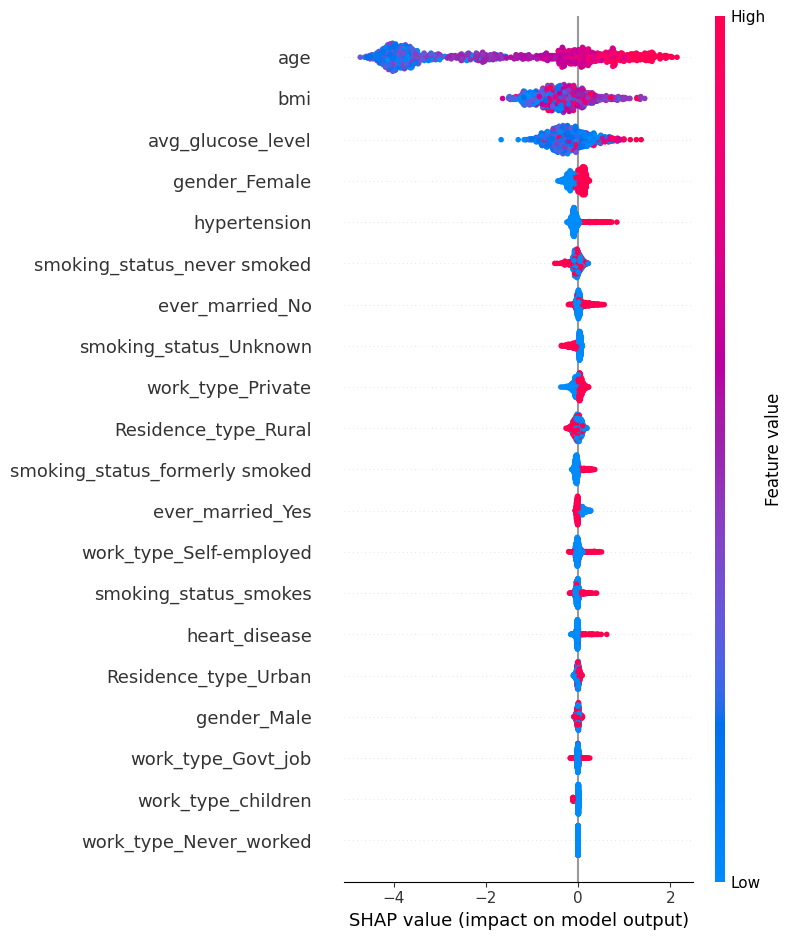

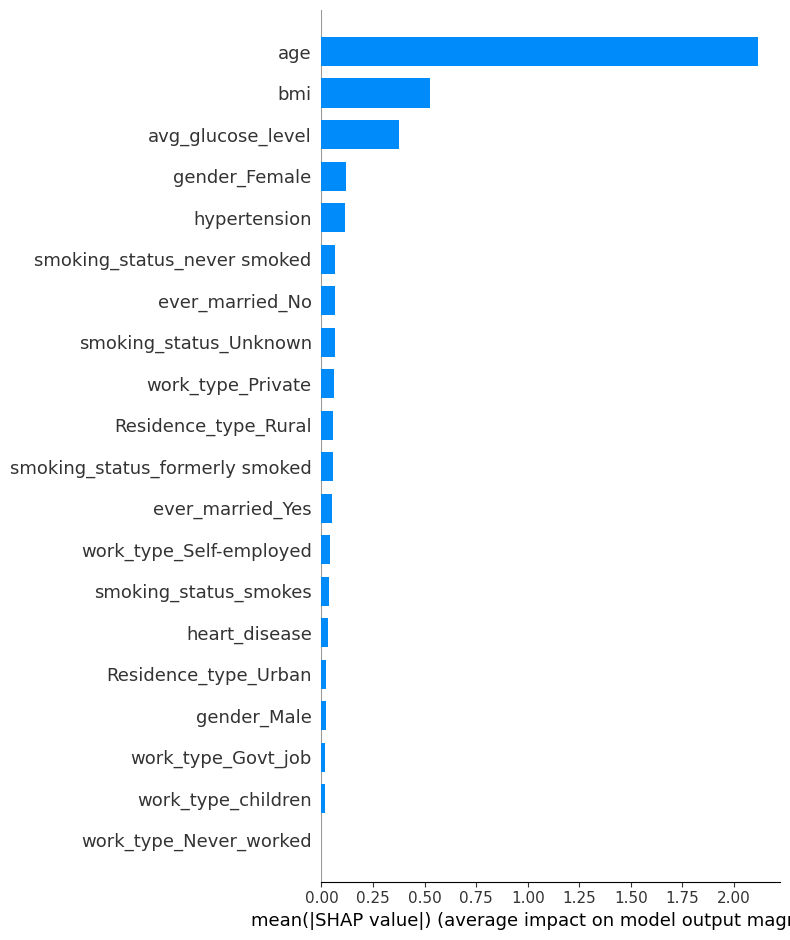

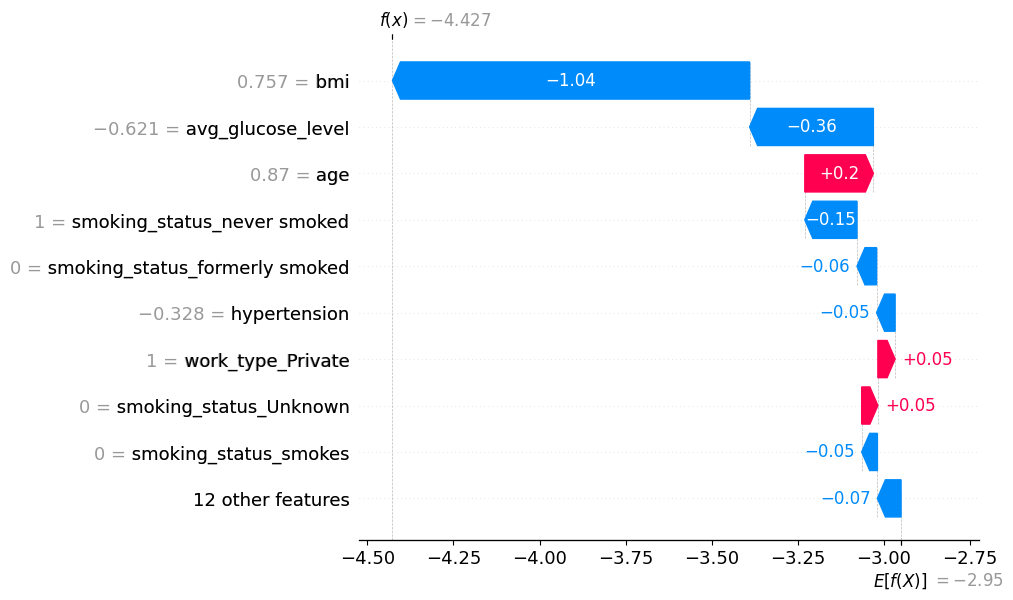

In [13]:
X_shap = X_test_tx_df

# SHAP 시각화를 위한 JavaScript 코드 초기화
shap.initjs() # SHAP (SHapley Additive exPlanations)라이브러리 사용해서 머신러닝 모델 예측 결과 해석 위한 시각화

# Summary plot
shap.summary_plot(shap_for_pos, X_shap, feature_names=feature_names)

# shap_for_pos : 모델의 SHAP 값
# Bar plot
shap.summary_plot(shap_for_pos, X_shap, feature_names=feature_names, plot_type="bar")

# Waterfall : 특정 샘플에 대해 예측을 어떻게 결정했는지를 설명하는 시각화입니다.
sample_i = 0
sv_row = shap_for_pos[sample_i] # 첫번째 샘플의 SHAP값

expected_value = explainer.expected_value # 예측 모델이 어떤 예측을 할 때 기본적으로 중립적인 예측값으로 사용하는 값
if isinstance(expected_value, (list, np.ndarray)) and len(expected_value) > 1:
    expected_value = expected_value[1]

shap.plots.waterfall(
    shap.Explanation(
        values=sv_row,
        base_values=expected_value,
        feature_names=feature_names,
        data=X_shap.iloc[sample_i]
    )
)


**Q2.** Summary plot/bar plot 결과에 대하여, **상위 3개 피처**가 모델에 어떤 의미를 주는지 설명해주세요.  

**A**
- age 변수 : 가장 중요한 피처로, Bar plot에서 가장 긴 막대를 차지하며, Summary plot에서도 점들이 가장 넓게 퍼져 있어 모델 예측에 가장 큰 영향을 미치는 것을 알 수 있음. Summary plot에서 붉은색 점(나이가 많음)은 SHAP 값이 양수(+) 방향에, 푸른색 점(나이가 적음)은 음수(-) 방향에 분포함. 이는 나이가 많을수록 모델의 예측값(질병 발생 확률)을 높이는 방향으로, 나이가 적을수록 예측값을 낮추는 방향으로 강하게 작용한다는 의미임.
- bmi (체질량 지수) : 두 번째로 중요한 피처, age와 마찬가지로 붉은색 점(BMI가 높음)들이 대체로 SHAP 값 양수(+) 영역에 위치함. 이는 BMI가 높을수록 모델의 예측값을 높이는 경향이 있음을 의미함. 즉, 비만일수록 질병 발생 가능성이 크다고 모델이 판단.
- avg_glucose_level (평균 혈당 수치) : 이 피처 역시 붉은색 점(평균 혈당이 높음)이 SHAP 값 양수(+) 영역에 집중되어 있음. 즉, 평균 혈당 수치가 높을수록 모델의 예측값을 높이는 데 기여함. 이는 일반적으로 혈당 수치가 높으면 특정 질병의 위험 요인이 되는 의학적 사실과 일치하는 것을 알 수 있음.

## 2번

이번에는 이미지 데이터에 적용할 수 있는 대표적인 XAI 기법인 **Grad-CAM**을 활용해봅니다.  
Grad-CAM은 합성곱 신경망(CNN)의 마지막 Convolution Layer의 Gradient를 활용하여,  
모델이 어떤 부분을 보고 해당 클래스로 예측했는지 **시각적으로 설명**해주는 방법입니다.

### 0) 환경 준비
Grad-CAM 구현에 필요한 패키지들을 불러옵니다.  
- `ResNet50` : 사전 학습된 대표적인 CNN 모델  
- `image` : 이미지 불러오기 및 전처리에 활용  
- `matplotlib` : 이미지 시각화에 사용


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import resnet50, ResNet50
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

### 1) 사전 학습된 모델 불러오기
`ImageNet` 데이터셋으로 학습된 **ResNet50** 모델을 불러옵니다.  
이 모델은 1,000개의 클래스를 분류할 수 있으며, 우리가 불러올 이미지를 어떤 클래스로 인식하는지도 확인할 수 있습니다.



In [15]:
model = ResNet50(weights = 'imagenet')
model.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

model.summary()`를 실행하면 ResNet50의 전체 구조(레이어, 파라미터 수 등)를 확인할 수 있습니다.  
특히 Grad-CAM은 **마지막 Convolution Layer**를 활용하므로, 모델 구조를 이해하는 게 중요합니다.

### 2)  테스트 이미지 불러오기
이제 Grad-CAM을 적용할 테스트 이미지를 불러옵니다.  
저는 골든 리트리버 사진 파일을 다운받아 sample_data 폴더에 업로드하여 사용했으며, ResNet50의 입력 크기인 `(224,224)`로 리사이즈합니다.

다른 물체 사진을 다운받아 다양하게 시도해보세요!



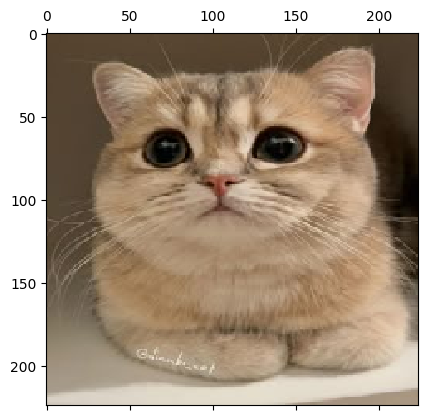

In [16]:
image_path='/content/sample_data/cat.jpg' # 사진 경로로 수정해주세요!
img = image.load_img(image_path, target_size=(224,224))
plt.matshow(img)

### 3) 이미지 전처리 & 예측 결과 확인
ResNet50 모델에 이미지를 넣기 전에 입력 형태에 맞게 전처리합니다.  
- `img_to_array` : 이미지를 숫자 배열로 변환  
- `expand_dims` : 배치 차원 추가 (모델 입력은 `(배치, 높이, 너비, 채널)` 형태)  
- `preprocess_input` : ResNet50 학습 시 사용된 방식대로 정규화  

마지막으로 `predict`를 통해 모델의 예측 결과를 확인합니다.


In [17]:
x = image.img_to_array(img)
x = np.expand_dims(x,axis=0)
x = resnet50.preprocess_input(x)

preds=model.predict(x)
print("예측 결과:", resnet50.decode_predictions(preds,top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
예측 결과: [('n02123394', 'Persian_cat', np.float32(0.47139853)), ('n02123045', 'tabby', np.float32(0.18907738)), ('n02123159', 'tiger_cat', np.float32(0.059917368)), ('n02124075', 'Egyptian_cat', np.float32(0.056984447)), ('n02971356', 'carton', np.float32(0.02983672))]


출력된 결과는 모델이 인식한 Top-5 클래스와 확률입니다.  
예를 들어 `Labrador retriever` 또는 `Golden retriever` 의 클래스로 높은 확률로 예측된 것을 확인할 수 있습니다!


### 4) Grad-CAM Heatmap 생성
이제 Grad-CAM을 구현해봅니다. 핵심 아이디어는 다음과 같습니다:
1. 마지막 Convolution Layer의 출력을 가져오기 (`conv5_block3_out`)  
2. 이 출력에 대해 관심 있는 클래스(class_id)의 Gradient를 계산  
3. 채널별 Gradient 평균값(`pooled_grads`)을 Feature Map에 가중치로 곱해줌  
4. 채널별 결과를 합쳐 Heatmap 생성  

즉, "이 클래스 예측에 가장 중요한 영역"을 시각적으로 표현하게 됩니다.


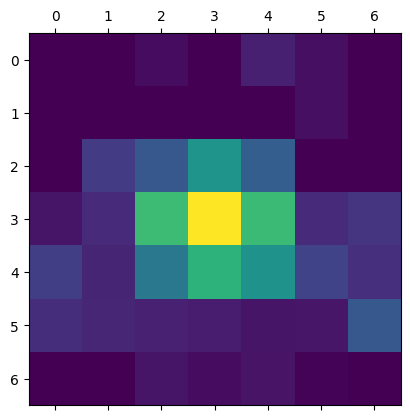

In [18]:
last_conv_layer=model.get_layer("conv5_block3_out")

model_1 = keras.Model(model.inputs,last_conv_layer.output)

input_2 = keras.Input(shape = last_conv_layer.output.shape[1:])
x_2=model.get_layer("avg_pool")(input_2)
x_2=model.get_layer("predictions")(x_2)
model_2=keras.Model(input_2,x_2)

with tf.GradientTape() as tape:
  output_1=model_1(x)
  tape.watch(output_1)
  preds=model_2(output_1)
  class_id=tf.argmax(preds[0])
  output_2=preds[:,class_id]

grads = tape.gradient(output_2,output_1)
pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))

output_1 = output_1.numpy()[0]
pooled_grads=pooled_grads.numpy()
for i in range(pooled_grads.shape[-1]):
  output_1[:,:,i]*=pooled_grads[i]
heatmap=np.mean(output_1,axis=-1)

heatmap=np.maximum(heatmap,0)/np.max(heatmap)
plt.matshow(heatmap)

위 결과로 출력된 Heatmap은 모델이 어떤 영역을 집중적으로 보았는지를 나타냅니다.  
아직은 원본 이미지와 분리된 형태라서 "강아지의 몸통" 또는 "얼굴" 같은 부위를 직접적으로 확인하긴 어렵습니다.


### 5) Heatmap을 원본 이미지에 Overlay
마지막으로 Heatmap을 원본 이미지 위에 겹쳐서 시각화합니다.  
- `jet colormap`을 이용해 Heatmap에 색상을 입힘  
- 원본 이미지 크기에 맞게 Resize  
- Overlay 후 결과 시각화

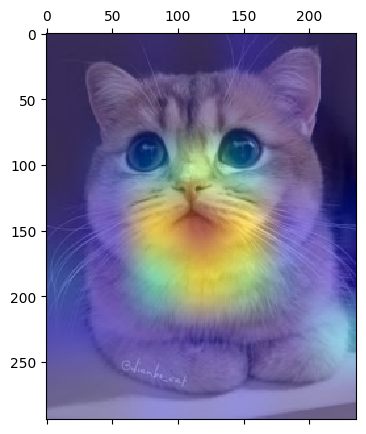

In [19]:
img=image.load_img(image_path)

img=image.img_to_array(img)
heatmap=np.uint8(255*heatmap)

jet=cm.get_cmap("jet")
color=jet(np.arange(256))[:,:3]
color_heatmap = color[heatmap]

color_heatmap = keras.preprocessing.image.array_to_img(color_heatmap)
color_heatmap = color_heatmap.resize((img.shape[1],img.shape[0]))
color_heatmap = keras.preprocessing.image.img_to_array(color_heatmap)

overlay_img=color_heatmap*0.7+img
overlay_img=keras.preprocessing.image.array_to_img(overlay_img)
plt.matshow(overlay_img)

이를 통해 **모델이 실제로 강아지의 어느 부위를 보고 '강아지'라고 인식했는지** 직관적으로 확인할 수 있습니다!

**Q3** 본인의 Grad-CAM 결과를 보고, 예측에 집중한 이미지 영역이 직관적으로 맞는지 설명해주세요

**A.**
- 모델의 예측: 모델은 이미지를 보고 **'페르시안 고양이(Persian_cat)'**라고 가장 높은 확률(약 47%)로 예측함.
- Grad-CAM 히트맵: 히트맵은 모델이 '페르시안 고양이'라고 판단하는 데 결정적인 영향을 미친 영역을 보여줌. 이 히트맵은 고양이의 얼굴 중앙, 특히 코와 입, 눈 주변에 집중되어 있음.
- > Grad-CAM 결과는 모델이 올바른 이미지 영역에 집중하여 페르시안 고양이라는 예측을 내렸음을 보여줌.